In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchtune.modules import RotaryPositionalEmbeddings
import csv
import os
from loss_curve_visualization import plot_loss_curves, Initialize_writer
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from sklearn.decomposition import PCA

C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = np.load(r"D:\Code\CAMZ\data\interim\boundingboxes_array.npy", allow_pickle=True)
rows_to_remove = [443, 474]
data = np.delete(data, rows_to_remove, axis=0)
print(f"Total original number of samples: {data.shape}")

Total original number of samples: (606, 300, 2)


In [3]:
mask = np.array([np.any(video == None) for video in data])
data = data[~mask]
data = data.astype(np.float32)
data.shape

(586, 300, 2)

In [4]:
# If not already done:
mean = data.mean(axis=(0, 1), keepdims=True)
std = data.std(axis=(0, 1), keepdims=True)
data = (data - mean) / std

In [5]:
labels_df = pd.read_csv(r"D:\Code\CAMZ\data\interim\verdict.csv")  # Adjust delimiter if needed
print(labels_df.head())

verdict = labels_df['Verdict']
verdicts = verdict[~mask]
print(verdicts.shape)

   Name  Inactivity score  Time_bottom score  Time_top score  \
0  1L.1                 0                  1               1   
1  1L.2                 0                  1               1   
2  1L.3                 0                  1               1   
3  1L.4                 0                  1               1   
4  1L.5                 0                  0               1   

   Large_angle score  Small_angle score  Final Score  Verdict  
0                  1                  0         0.50        1  
1                  1                  0         0.50        1  
2                  1                  1         0.70        1  
3                  0                  1         0.50        1  
4                  1                  1         0.55        1  
(586,)


In [6]:
labels_df = labels_df[~mask]
labels_df

,Name,Inactivity score,Time_bottom score,Time_top score,Large_angle score,Small_angle score,Final Score,Verdict
0,1L.1,0,1,1,1,0,0.50,1
1,1L.2,0,1,1,1,0,0.50,1
2,1L.3,0,1,1,1,1,0.70,1
3,1L.4,0,1,1,0,1,0.50,1
4,1L.5,0,0,1,1,1,0.55,1
...,...,...,...,...,...,...,...,...
601,10L.31,0,1,1,0,0,0.30,0
602,10L.32,0,1,1,0,0,0.30,0
603,10L.33,0,1,1,0,0,0.30,0
604,10L.34,0,0,0,1,0,0.20,0


In [8]:
data = torch.tensor(data, dtype=torch.float32)

# Calculate split sizes
total_samples = data.shape[0]
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

# Split datasets
train_data, val_data, test_data = random_split(data, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [7]:
import torch
import torch.nn as nn

class TransformerAutoencoder(nn.Module):
    def __init__(self, input_dim=2, seq_len=300, latent_dim=64, num_heads=4, ff_dim=512, num_layers=4):
        super(TransformerAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.head_dim = latent_dim // num_heads

        # Input projection
        self.input_proj = nn.Linear(input_dim, latent_dim)
        self.pos_encoding = RotaryPositionalEmbeddings(dim=self.head_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.encoder_norm = nn.LayerNorm(latent_dim)
        # Latent vector via pooling
        self.latent_pool = nn.AdaptiveAvgPool1d(1)
        
        self.projection_head = nn.Sequential(
        nn.Linear(latent_dim, latent_dim),
        nn.ReLU(),
        nn.Linear(latent_dim, latent_dim)
        )


    def apply_rope(self, x):
        # x: (B, S, D)
        B, S, D = x.shape
        x = x.view(B, S, self.num_heads, self.head_dim)   # (B, S, N_H, H_D)
        x = self.pos_encoding(x)                          # Apply RoPE
        x = x.view(B, S, D)                               # Back to (B, S, D)
        return x
    
    def add_noise(self, x, noise_std=0.01):
        return x + noise_std * torch.randn_like(x)

    def rotate(self, x, angle_range=(-15, 15)):
        angle = torch.empty(1).uniform_(*angle_range).item()
        rad = torch.deg2rad(torch.tensor(angle))
        rotation_matrix = torch.tensor([
            [torch.cos(rad), -torch.sin(rad)],
            [torch.sin(rad),  torch.cos(rad)]
        ], device=x.device)
        return torch.matmul(x, rotation_matrix)
    
    def augment(self, x):
        if torch.rand(1).item() < 0.5:
            x = self.add_noise(x)
        else:
            x = self.rotate(x)
        return x

    def forward(self, x, apply_aug=True):
        if apply_aug:
            x = self.augment(x)  # Apply noise or rotation only if True

        x = self.input_proj(x)  # (B, S, latent_dim)
        x = self.apply_rope(x)
        x = self.encoder_norm(self.encoder(x))
        x_pooled = self.latent_pool(x.permute(0, 2, 1)).squeeze(-1)
        z = self.projection_head(x_pooled)
        z = nn.functional.normalize(z, dim=1)

        return z


In [8]:

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.cosine_similarity = nn.CosineSimilarity(dim=-1)

    def forward(self, z1, z2):
        """
        z1, z2: Tensor of shape (B, D) — representations from two views
        """
        B = z1.size(0)
        z = torch.cat([z1, z2], dim=0)  # (2B, D)

        # Normalize representations
        z = F.normalize(z, dim=1)

        # Cosine similarity matrix (2B x 2B)
        sim = torch.matmul(z, z.T) / self.temperature

        # Mask out self-similarities
        mask = torch.eye(2 * B, dtype=torch.bool).to(z.device)
        sim.masked_fill_(mask, -1e9)

        # Create labels for positive pairs
        targets = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)

        # Compute cross-entropy loss
        loss = F.cross_entropy(sim, targets)
        return loss

In [9]:
x = torch.rand((32, 300, 2))
model = TransformerAutoencoder()
x1 = model(x)
x2 = model(x)
print(x1.shape, x2.shape)

loss = NTXentLoss()
print(loss(x1, x2))

torch.Size([32, 64]) torch.Size([32, 64])
tensor(4.1454, grad_fn=<NllLossBackward0>)


In [10]:
model = TransformerAutoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = NTXentLoss(temperature=0.1)

history_path = r"D:\Code\CAMZ\models\model_history\transformer_history.csv"
save_model_checkpoint_path = r"D:\Code\CAMZ\models\transformer.pth.tar"


In [23]:
def Initialize_writer(file_path):
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    with open(file_path, mode='w', newline="") as file:
        writer = csv.writer(file)
        writer.writerow(['epoch', 'loss', 'val_loss'])

In [24]:
def validate(model, val_loader, loss_function, device='cpu'):
    model.eval()
    total_batch_loss = 0.0
    with torch.no_grad():
        for inputs in val_loader:
            inputs = inputs.to(device)
            outputs1 = model(inputs)
            outputs2 = model(inputs)
            loss_per_batch = loss_function(outputs1, outputs2)
            total_batch_loss += loss_per_batch.item()
        total_loss = total_batch_loss / len(val_loader)
        print(f"NXent Loss: {total_loss:.4f}", end=" ")
    return total_loss

def train(model, train_loader, val_loader, optimizer, 
                      loss_function, history_csv_path, 
                      save_model_checkpoint_path, num_epochs=100, 
                      patience=10, delta=0.001, device='cpu'):

    Initialize_writer(history_csv_path)
    
    best_val_loss = float('inf')
    early_stopping = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)
            
            z1 = model(batch)
            z2 = model(batch)

            loss = loss_function(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], Train Contrastive Loss: {avg_train_loss:.4f}", end=" --- ")
        val_loss = validate(model, val_loader, loss_function, device='cpu')

        # Early stopping and checkpoint logic
        if (best_val_loss - val_loss) > delta:
            best_val_loss = val_loss
            checkpoint = {'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict()}
            print(f"\n=========Saving Checkpoint======= at Epoch:[{epoch+1}/{num_epochs}]")
            torch.save(checkpoint, save_model_checkpoint_path)
            early_stopping = 0
        else:
            early_stopping += 1

        # Log to CSV
        with open(history_csv_path, mode='a', newline="") as file:
            loss_writer = csv.writer(file)
            loss_writer.writerow([epoch+1, avg_train_loss, val_loss])

        if early_stopping >= patience:
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break

    print(f"\n Best Validation Loss: {best_val_loss:.4f}")


In [25]:
train(model, train_loader, val_loader = val_loader, optimizer=optimizer, loss_function=criterion,
      history_csv_path=history_path,
      save_model_checkpoint_path=save_model_checkpoint_path, num_epochs=10)


Epoch [1/10], Train Contrastive Loss: 1.4032 --- NXent Loss: 0.9939 
=========Saving Checkpoint======= at Epoch:[1/10]

Epoch [2/10], Train Contrastive Loss: 0.7150 --- NXent Loss: 0.5454 
=========Saving Checkpoint======= at Epoch:[2/10]

Epoch [3/10], Train Contrastive Loss: 0.5958 --- NXent Loss: 0.5087 
=========Saving Checkpoint======= at Epoch:[3/10]

Epoch [4/10], Train Contrastive Loss: 0.4320 --- NXent Loss: 0.3732 
=========Saving Checkpoint======= at Epoch:[4/10]

Epoch [5/10], Train Contrastive Loss: 0.3885 --- NXent Loss: 0.5153 
Epoch [6/10], Train Contrastive Loss: 0.3997 --- NXent Loss: 0.2118 
=========Saving Checkpoint======= at Epoch:[6/10]

Epoch [7/10], Train Contrastive Loss: 0.3207 --- NXent Loss: 0.1732 
=========Saving Checkpoint======= at Epoch:[7/10]

Epoch [8/10], Train Contrastive Loss: 0.2747 --- NXent Loss: 0.2800 
Epoch [9/10], Train Contrastive Loss: 0.3113 --- NXent Loss: 0.2147 
Epoch [10/10], Train Contrastive Loss: 0.2296 --- NXent Loss: 0.2297 
 B

The best loss of 0.22960581859717 achieved at Epoch: 10


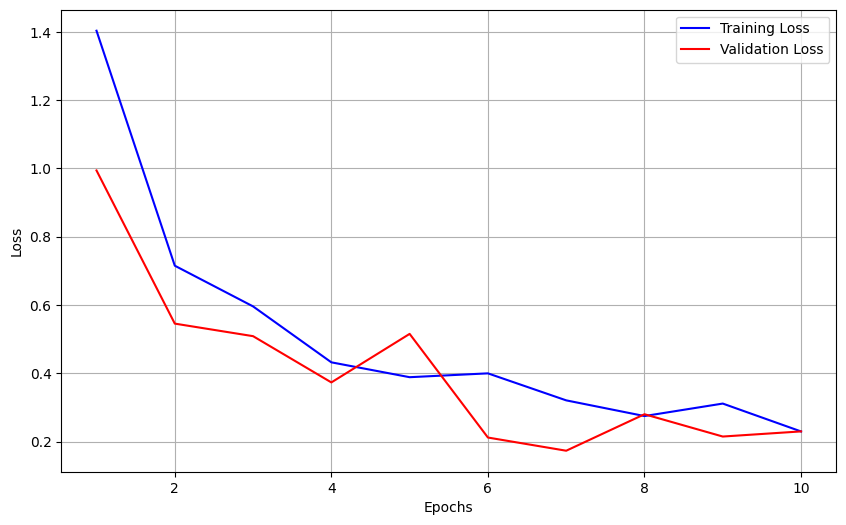

In [26]:
from loss_curve_visualization import plot_loss_curves
plot_loss_curves(r"E:\Code\CAMZ\models\model_history\transformer_history.csv")

In [11]:
def load_checkpoint(checkpoint, architecture, optimizer):
    print("loading checkpoint...")
    checkpoint = torch.load(checkpoint)
    
    model = architecture()
    
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])

    return model.eval()
model = load_checkpoint(r"D:\Code\CAMZ\models\transformer.pth.tar", TransformerAutoencoder, optimizer)

loading checkpoint...


C:\Users\HARSHU\AppData\Local\Temp\ipykernel_628\3200180624.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint)


In [12]:
data = torch.tensor(data, dtype=torch.float32)
# Create DataLoaders
batch_size = 32
data_loader = DataLoader(data, batch_size=batch_size, shuffle=False)

In [13]:
def extract_latents(model, data_loader, device='cpu'):
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            z = model(batch)
            latents.append(z.cpu())

    return torch.cat(latents, dim=0)  # shape: (N, latent_dim)


In [14]:
latents = extract_latents(model, data_loader)

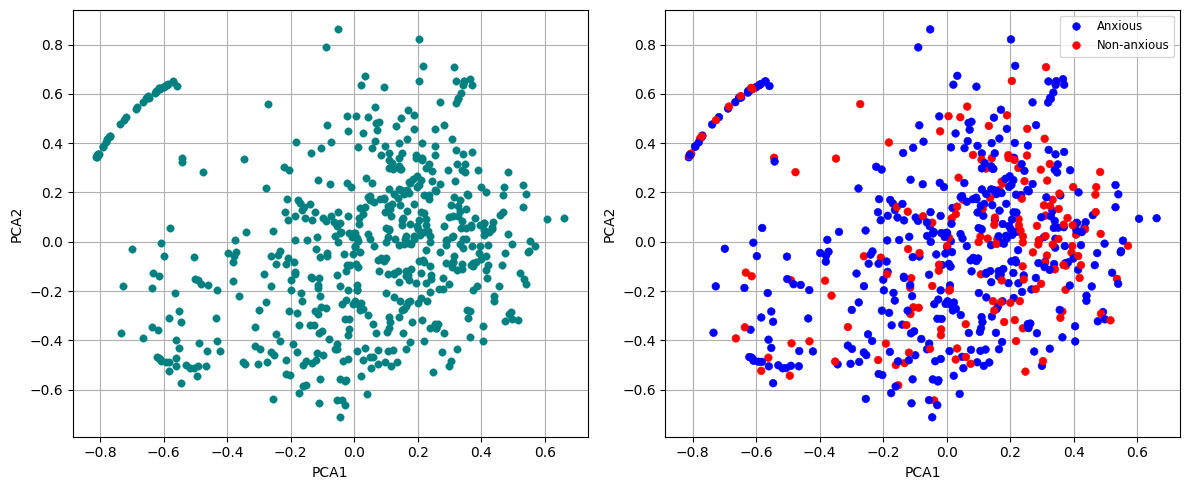

In [49]:
pca = PCA(n_components=2)
pca_latents = pca.fit_transform(latents)

df = pd.DataFrame(pca_latents, columns=['PCA1', 'PCA2'])
label_map = {0: 'Non-anxious', 1: 'Anxious'}
df['Label'] = [label_map[int(l)] for l in verdicts]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCA without labels
sns.scatterplot(data=df, x='PCA1', y='PCA2', ax=axes[0], s=30, edgecolor=None, color='teal', linewidth=0.2)
axes[0].set_axisbelow(True)
axes[0].grid(True)

# PCA with labels
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Label', palette=['blue', 'red'], ax=axes[1], s=30, edgecolor=None)
axes[1].legend(loc='best', fontsize='small')
axes[1].set_axisbelow(True)
axes[1].grid(True)

# Adjust layout for a clean look
plt.tight_layout()
plt.show()


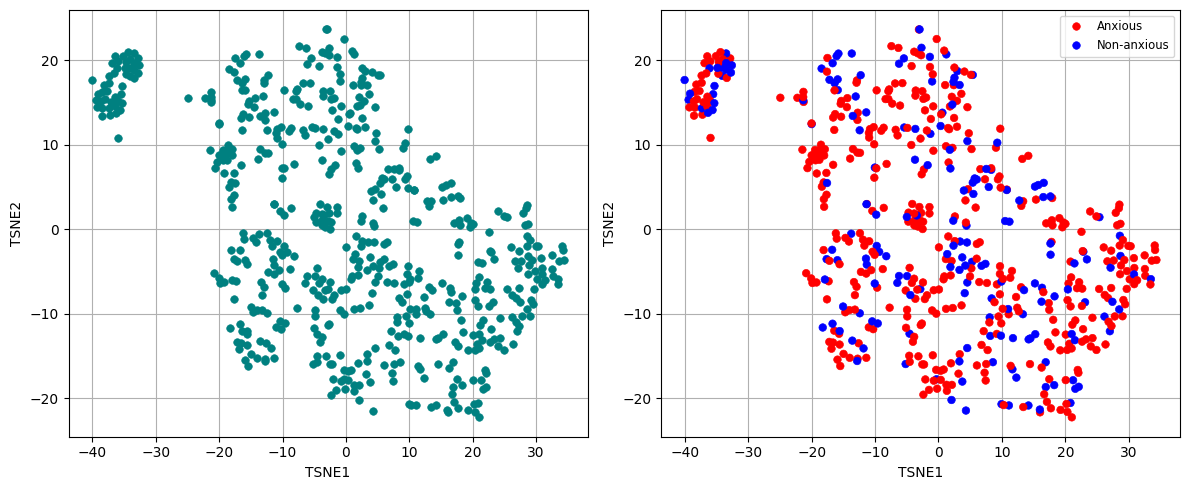

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE


# Step 1: Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_latents = tsne.fit_transform(latents)  # `latents` shape: (N, latent_dim)

# Step 2: Create DataFrame with custom label names
label_map = {0: 'Non-anxious', 1: 'Anxious'}
df_tsne = pd.DataFrame(tsne_latents, columns=['TSNE1', 'TSNE2'])
df_tsne['Label'] = [label_map[int(l)] for l in verdicts]

# Step 4: Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: t-SNE without labels
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', ax=axes[0], color='teal', s=30, edgecolor=None)
axes[0].grid(True)
axes[0].set_axisbelow(True)

# Right: t-SNE with labels
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Label', palette={'Non-anxious':'blue', 'Anxious':'red'}, ax=axes[1], s=30,edgecolor=None)
axes[1].legend(loc='best', fontsize='small')
axes[1].grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


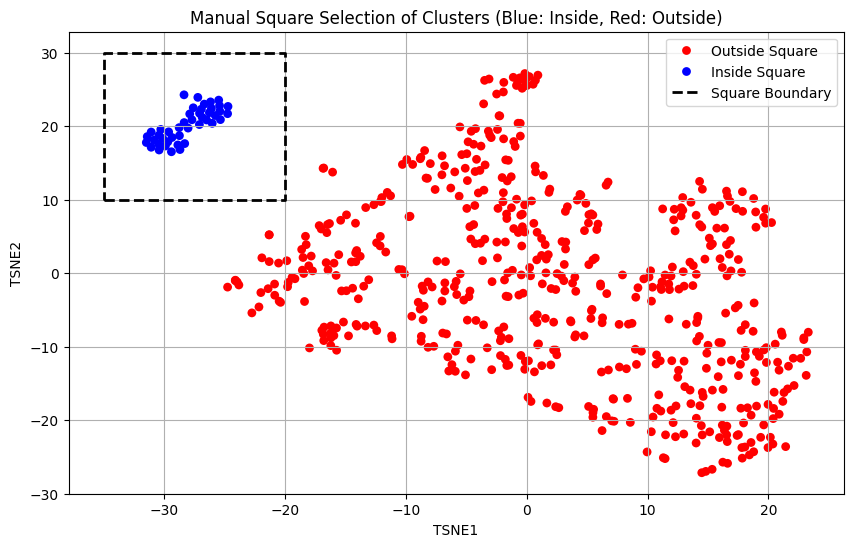

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Define the square boundaries (adjust these values!)
square_x_min, square_x_max = -35, -20  # TSNE1 range
square_y_min, square_y_max = 10, 30    # TSNE2 range

# Step 2: Assign labels (1 = inside square, 0 = outside)
labels = np.where(
    (tsne_latents[:, 0] >= square_x_min) & (tsne_latents[:, 0] <= square_x_max) & 
    (tsne_latents[:, 1] >= square_y_min) & (tsne_latents[:, 1] <= square_y_max),
    1,  # Points inside square (smaller cluster)
    0   # Points outside square (bigger cluster)
)

# Step 3: Create DataFrame for plotting
tsne_df = pd.DataFrame(tsne_latents, columns=["TSNE1", "TSNE2"])
tsne_df["Cluster"] = ["Inside Square" if label == 1 else "Outside Square" for label in labels]

# Step 4: Plot
plt.figure(figsize=(10, 6))

# Scatter plot with manual labels
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cluster",
    palette={"Inside Square": "blue", "Outside Square": "red"},
    s=40,
    edgecolor="none"
)

# Draw the square boundary
plt.plot(
    [square_x_min, square_x_max, square_x_max, square_x_min, square_x_min],
    [square_y_min, square_y_min, square_y_max, square_y_max, square_y_min],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Square Boundary"
)

plt.title("Manual Square Selection of Clusters (Blue: Inside, Red: Outside)")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
labels_df

,Name,Inactivity score,Time_bottom score,Time_top score,Large_angle score,Small_angle score,Final Score,Verdict
0,1L.1,0,1,1,1,0,0.50,1
1,1L.2,0,1,1,1,0,0.50,1
2,1L.3,0,1,1,1,1,0.70,1
3,1L.4,0,1,1,0,1,0.50,1
4,1L.5,0,0,1,1,1,0.55,1
...,...,...,...,...,...,...,...,...
601,10L.31,0,1,1,0,0,0.30,0
602,10L.32,0,1,1,0,0,0.30,0
603,10L.33,0,1,1,0,0,0.30,0
604,10L.34,0,0,0,1,0,0.20,0


In [16]:
import pandas as pd
import numpy as np

# df = pd.read_csv(...)   # ← your existing DataFrame

# list of “special” prefixes that should map to group 0
special_prefixes = ['1L', '3L', '7L', '9L', '10L',
                    '2R', '4R', '6R', '8R']

# grab the part before the first dot (e.g. “1L” from “1L.1”)
name_prefix = labels_df['Name'].str.split('.', n=1).str[0]

# assign 0 if prefix is in the special list, else 1
labels_df['group'] = np.where(name_prefix.isin(special_prefixes), 0, 1)


In [21]:
labels_df

,Name,Inactivity score,Time_bottom score,Time_top score,Large_angle score,Small_angle score,Final Score,Verdict,group
0,1L.1,0,1,1,1,0,0.50,1,0
1,1L.2,0,1,1,1,0,0.50,1,0
2,1L.3,0,1,1,1,1,0.70,1,0
3,1L.4,0,1,1,0,1,0.50,1,0
4,1L.5,0,0,1,1,1,0.55,1,0
...,...,...,...,...,...,...,...,...,...
601,10L.31,0,1,1,0,0,0.30,0,0
602,10L.32,0,1,1,0,0,0.30,0,0
603,10L.33,0,1,1,0,0,0.30,0,0
604,10L.34,0,0,0,1,0,0.20,0,0


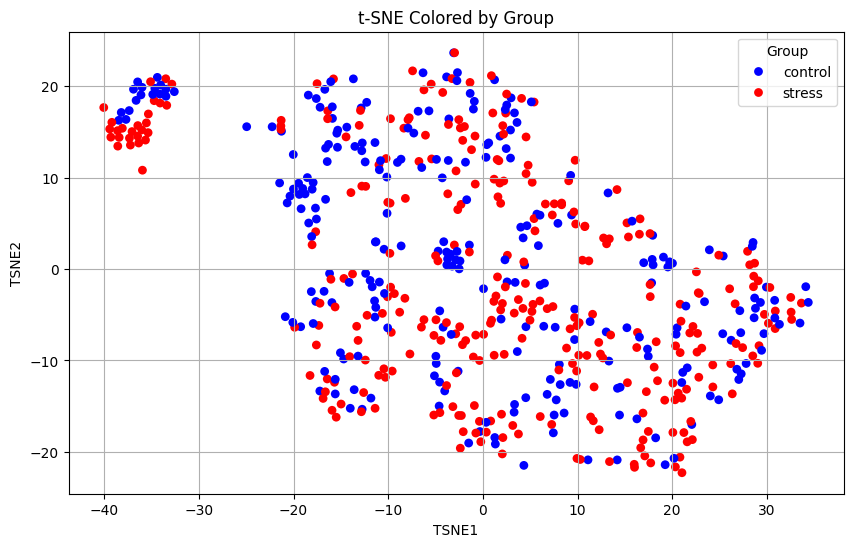

In [31]:
import matplotlib.pyplot as plt
import pandas as pd



# Step 3: Create DataFrame for plotting
tsne_df = pd.DataFrame(tsne_latents, columns=["TSNE1", "TSNE2"])
tsne_df['group'] = labels_df['group']
tsne_df['group_label'] = tsne_df['group'].map({0: 'control', 1: 'stress'})
# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="group_label",             # use string-based column
    palette={'control': 'blue', 'stress': 'red'},
    s=40,
    edgecolor="none"
)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.title("t-SNE Colored by Group")
plt.grid(True)
plt.legend(title="Group")
plt.show()

C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\HARSHU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


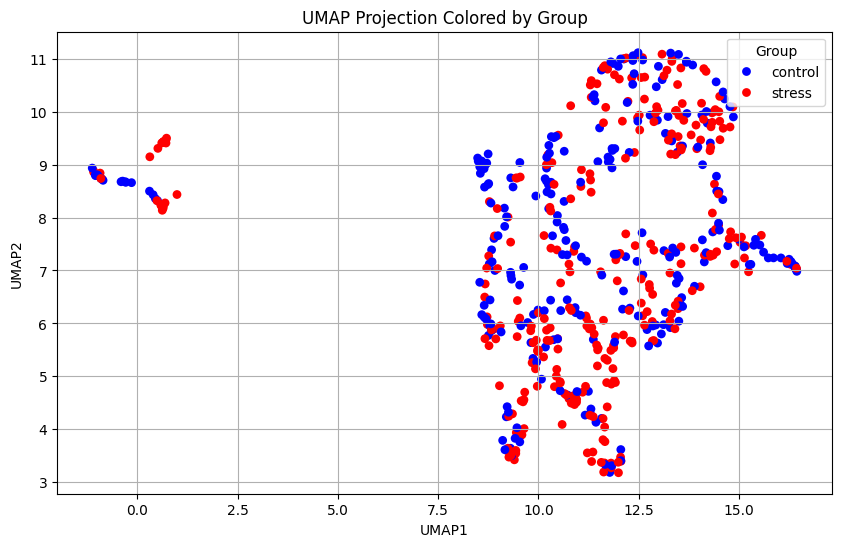

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP



# Step 1: Run UMAP on the transformer features
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_latents = umap_model.fit_transform(latents)

# Step 2: Create DataFrame for plotting
umap_df = pd.DataFrame(umap_latents, columns=["UMAP1", "UMAP2"])
umap_df['group'] = labels_df['group']
umap_df['group_label'] = umap_df['group'].map({0: 'control', 1: 'stress'})  # string labels

# Step 3: Plot with seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="group_label",
    palette={'control': 'blue', 'stress': 'red'},
    s=40,
    edgecolor="none"
)
plt.title("UMAP Projection Colored by Group")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(True)
plt.legend(title="Group")
plt.show()


In [41]:
labels_df['cluster_ids'] = labels

In [48]:
labels_df[labels_df['cluster_ids'] == 1]

,Name,Inactivity score,Time_bottom score,Time_top score,Large_angle score,Small_angle score,Final Score,Verdict,cluster_ids
95,2L.36,0,1,1,0,1,0.50,1,1
96,2L.37,0,0,1,0,1,0.35,0,1
97,2R.1,0,1,1,0,0,0.30,0,1
98,2R.2,0,1,1,0,1,0.50,1,1
99,2R.3,0,1,1,0,1,0.50,1,1
100,2R.4,0,1,1,1,0,0.50,1,1
106,2R.10,0,1,1,1,1,0.70,1,1
117,2R.21,0,0,0,0,0,0.00,0,1
126,2R.30,0,1,1,0,0,0.30,0,1
127,2R.31,0,1,1,0,0,0.30,0,1


In [47]:
small_clusters = labels_df[labels_df['cluster_ids'] == 1]

In [50]:
small_clusters.to_excel('D:\Code\CAMZ\data\interim\small_cluster_samples.xlsx')

C:\Users\HARSHU\AppData\Local\Temp\ipykernel_18444\2250118960.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(selected_data, dtype=torch.float32).to('cpu')


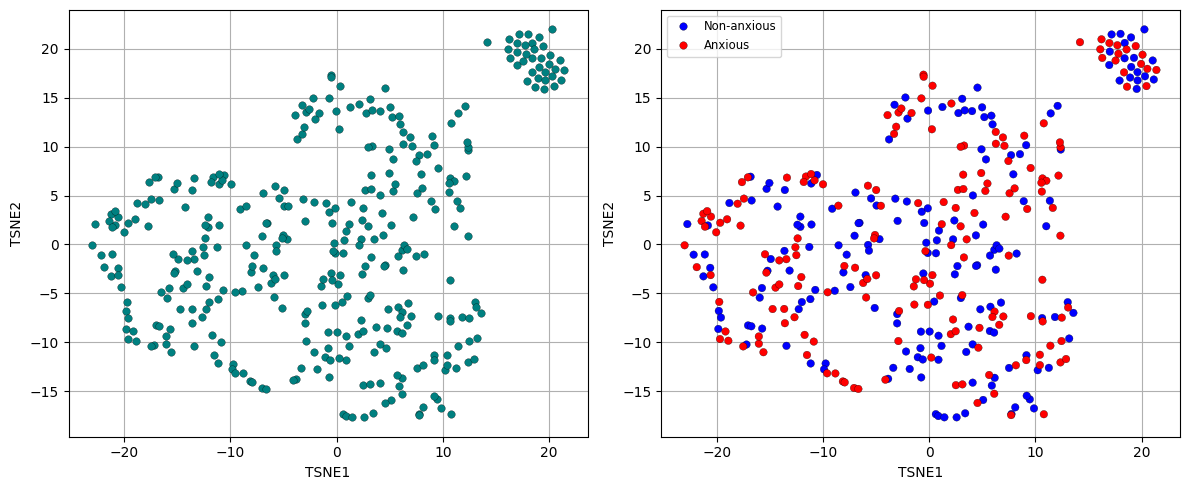

In [58]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

n_samples = 179

class_0_indices = np.where(np.array(verdicts) == 0)[0]
class_1_indices = np.where(np.array(verdicts) == 1)[0]

np.random.seed(42)
sampled_0 = np.random.choice(class_0_indices, n_samples, replace=False)
sampled_1 = np.random.choice(class_1_indices, n_samples, replace=False)

selected_indices = np.concatenate([sampled_0, sampled_1])
selected_labels = np.array(verdicts)[selected_indices]
selected_data = data[selected_indices]

# Model inference
x_tensor = torch.tensor(selected_data, dtype=torch.float32).to('cpu')
model.eval()
with torch.no_grad():
    selected_latents = model(x_tensor).cpu().numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_selected = tsne.fit_transform(selected_latents)

label_map = {0: 'Non-anxious', 1: 'Anxious'}
label_names = [label_map[int(l)] for l in selected_labels]
df_tsne = pd.DataFrame(tsne_selected, columns=['TSNE1', 'TSNE2'])
df_tsne['Label'] = label_names

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: t-SNE without labels
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', ax=axes[0], color='teal', s=30, edgecolor='black', linewidth=0.2)
axes[0].grid(True)
axes[0].set_axisbelow(True)

# Right: t-SNE with labels
palette = {'Non-anxious': 'blue', 'Anxious': 'red'}
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Label', palette=palette, ax=axes[1], s=30, edgecolor='black', linewidth=0.2)
axes[1].legend(loc='best', fontsize='small')
axes[1].grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()
